In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Load dataset (similar to MNIST but lighter)
data = load_digits()
X = data.data
y_original = data.target # Store original y

# Convert to binary classification: 0 vs. not 0
y = (y_original == 0).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

# Helper function
def evaluate_model(name, model):
    # Train
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    # Predict
    start_pred = time.time()
    y_pred = model.predict(X_test)
    end_pred = time.time()

    # For binary classification, ensure predictions are 0 or 1 for Linear Regression
    if name == "Linear Regression":
        y_pred_classified = (y_pred > 0.5).astype(int)
        acc = accuracy_score(y_test, y_pred_classified)
    else:
        acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Train Time (s)": end_train - start_train,
        "Inference Time (s)": end_pred - start_pred,
        "Accuracy": acc
    })

# 1. Linear Regression (used as classifier via rounding)
lr = LinearRegression()
evaluate_model("Linear Regression", lr)

# 2. Logistic Regression
logreg = LogisticRegression(max_iter=500)
evaluate_model("Logistic Regression", logreg)

# 3. KNN
knn = KNeighborsClassifier(n_neighbors=3)
evaluate_model("KNN", knn)

# 4. SVM
svm = SVC()
evaluate_model("SVM", svm)

# 5. Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300)
evaluate_model("Neural Network", mlp)

# Results
df = pd.DataFrame(results)
print(df)

                 Model  Train Time (s)  Inference Time (s)  Accuracy
0    Linear Regression        0.033340            0.000449  0.997222
1  Logistic Regression        0.083201            0.000885  0.997222
2                  KNN        0.006117            0.063919  1.000000
3                  SVM        0.010904            0.003845  1.000000
4       Neural Network        1.462653            0.009109  1.000000


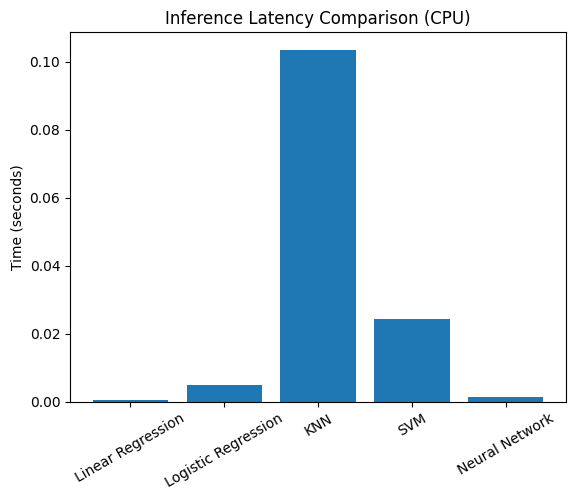

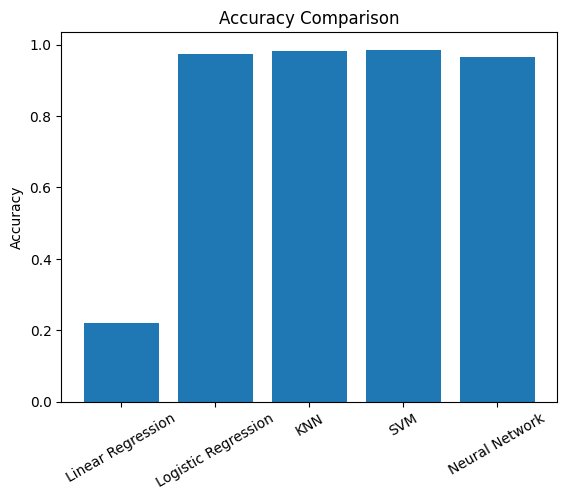

In [ ]:
import matplotlib.pyplot as plt

# Inference Time Plot
plt.figure()
plt.bar(df["Model"], df["Inference Time (s)"])
plt.xticks(rotation=30)
plt.ylabel("Time (seconds)")
plt.title("Inference Latency Comparison (CPU)")
plt.show()

# Accuracy Plot
plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

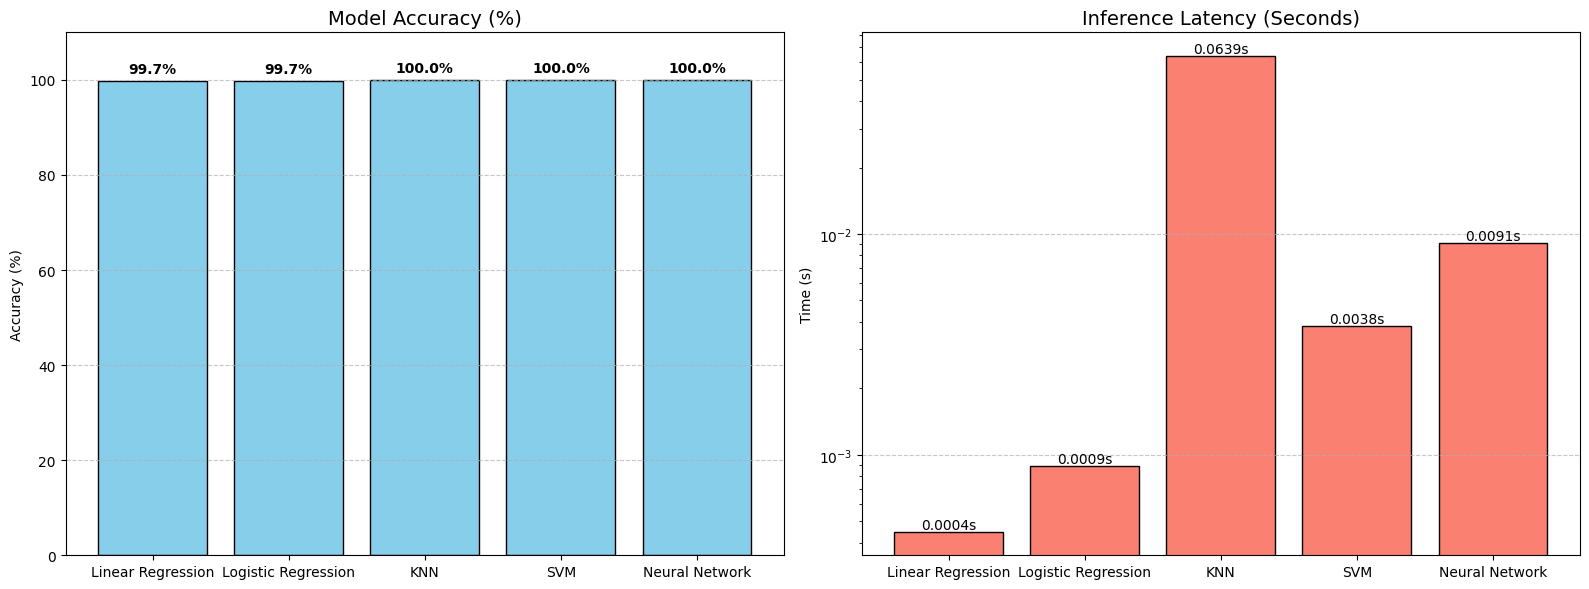

In [3]:
import matplotlib.pyplot as plt

# Extract data from your results list
names = [r["Model"] for r in results]
train_times = [r["Train Time (s)"] for r in results]
inf_times = [r["Inference Time (s)"] for r in results]
accuracies = [r["Accuracy"] for r in results]

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy (Percentage)
bars1 = ax1.bar(names, [a * 100 for a in accuracies], color='skyblue', edgecolor='black')
ax1.set_title('Model Accuracy (%)', fontsize=14)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Inference Latency (Log Scale recommended because KNN is so much slower)
bars2 = ax2.bar(names, inf_times, color='salmon', edgecolor='black')
ax2.set_title('Inference Latency (Seconds)', fontsize=14)
ax2.set_ylabel('Time (s)')
ax2.set_yscale('log')  # Using log scale to see the fast models clearly next to KNN
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels for timing
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

# Load MNIST
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Normalize
X = X / 255.0

# Reduce dataset for speed (important)
X = X[:10000]
y = y[:10000]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train NN
model = MLPClassifier(hidden_layer_sizes=(64,), max_iter=20)

start_train = time.time()
model.fit(X_train, y_train)
end_train = time.time()

# Predict
start_pred = time.time()
y_pred = model.predict(X_test)
end_pred = time.time()

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("Inference Time:", end_pred - start_pred)

Accuracy: 0.944
Inference Time: 0.018118858337402344


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
